In [64]:
import os
import sys
import numpy as np
import pandas as pd
# we will only import certain module from those libraries
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from datetime import datetime
import plotly.graph_objects as go
import plotly.express as px
import math
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from random import randrange
import argparse
import collections
import tensorflow as tf
import logging
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Bidirectional, LSTM, Flatten, Dense, Reshape, UpSampling1D, TimeDistributed
from tensorflow.keras.layers import Activation, Conv1D, LeakyReLU, Dropout, Add, Layer
from tensorflow.compat.v1.keras.layers import CuDNNLSTM
from tensorflow.keras.optimizers import Adam
import pydot
import pydotplus
from pydotplus import graphviz
from scipy import stats
from scipy import integrate
from scipy.optimize import fmin
from pyts.metrics import dtw
from pandas.plotting import register_matplotlib_converters

In [65]:
#
# hyper parameters
#
win_size =10
features_dim =3
feat_dim = features_dim
params = {}
params['plot_network'] =True
params['epochs'] =30
params['batch_size'] =64
params['n_critic'] =5
params['learning_rate'] =0.0005
params['latent_dim'] =20
params['shape'] = [win_size, features_dim]
params['encoder_input_shape'] = [win_size, features_dim]
params['encoder_reshape_shape'] = [20, 1]
params['generator_input_shape'] = [20, 1]
params['generator_reshape_shape'] = [win_size, 1]
params['critic_x_input_shape'] = [win_size, features_dim]
params['critic_z_input_shape'] = [20, 1]
print("win_size = %d, features_dim = %d " % (win_size, features_dim))

win_size = 10, features_dim = 3 


In [66]:
arguments=collections.namedtuple('Args',
 'signal_file timest_form anomaly_file mode aggregate_interval regate_interval')

args=arguments(signal_file = './data/preprocessed/train/1000_chg.csv',
 timest_form = 0,
 anomaly_file = '',
 mode = 'train',
 aggregate_interval = 1,
 regate_interval = 1)
print("argments")
print("----------------------")
print("args.timest_form :", args.timest_form)
print("args.signal_file :", args.signal_file)
print("args.anomaly_file :", args.anomaly_file)
print("args.mode :", args.mode)
print("args.aggregate_interval :", args.aggregate_interval)
print("----------------------\n")

argments
----------------------
args.timest_form : 0
args.signal_file : ./data/preprocessed/train/1000_chg.csv
args.anomaly_file : 
args.mode : train
args.aggregate_interval : 1
----------------------



In [67]:
diffs_n = 0 # take differences
lags_n = 0 # include lags in the feature vector
smooth_n = 0 # smooth the latest values to be included in the feature vector
print("diffs_n: ", diffs_n)
#
def diff_smooth_df(df, lags_n, diffs_n, smooth_n, diffs_abs=False, abs_features=False):
 #Given a pandas dataframe preprocess it to take differences, add smoothing, and lags as specified.
    if diffs_n >=1:
    # take differences
        df = df.diff(diffs_n).dropna()
    # abs diffs if defined
        if diffs_abs ==True:
            df = abs(df)
    if smooth_n >=2:
    # apply a rolling average to smooth out the data a bit
        df = df.rolling(smooth_n).mean().dropna()
    if lags_n >=1:
 # for each dimension add a new columns for each of lags_n lags of the differenced and smoothed values for that dimension
        df_columns_new = [f'{col}_lag{n}'for n in range(lags_n+1) for col in df.columns]
        df = pd.concat([df.shift(n) for n in range(lags_n+1)], axis =1).dropna()
        df.columns = df_columns_new
 # sort columns to have lagged values next to each other for clarity when looking at the feature vectors
    df = df.reindex(sorted(df.columns), axis =1)
 # abs all features if specified
    if abs_features ==True:
        df = abs(df)
    return df
print("import diff_smooth_df() : Done ! " )

diffs_n:  0
import diff_smooth_df() : Done ! 


In [68]:
######## PCA reduction of data ################################
signal_path = args.signal_file
df_train_0= pd.read_csv(signal_path)
data_0 = df_train_0 # copy
# preprocess or ‘featurize’ the training data
data_1 = diff_smooth_df(data_0, lags_n, diffs_n, smooth_n)
pca = PCA(n_components=features_dim)
data = pca.fit_transform(data_1) # Dimensional reduction of Train Data by PCA
df_1 = []
for i in range(len(data)):
    row = [i+1] # attach index of integers
    for jj in range(features_dim):
        row.append(data[i][jj])
    df_1.append(row)
df = pd.DataFrame(df_1)
columns_new = ['date']
for i in range(1, features_dim+1):
    pca_i = 'pca_%s' % str(i)
    columns_new.append(pca_i)
df.columns = columns_new
print("After PCA reduction df.shape = ", df.shape)
print("----------------------")
print(df.head(5))
print("----------------------")
print("\n")

After PCA reduction df.shape =  (6009, 4)
----------------------
   date      pca_1     pca_2     pca_3
0     1  18.488237  0.590387 -0.223252
1     2  18.489667  0.596742 -0.252020
2     3  18.489788  0.596241 -0.252126
3     4  18.488254  0.590316 -0.223271
4     5  18.520762  0.590422 -0.187038
----------------------




In [69]:
def time_segments_aggregate(X, interval, time_column, method=['mean']):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    X = X.sort_values(time_column).set_index(time_column)
    if isinstance(method, str):
        method = [method]
    start_ts = X.index.values[0]
    max_ts = X.index.values[-1]
    values = list()
    index = list()
    while start_ts <= max_ts:
        end_ts = start_ts + interval
        subset = X.loc[start_ts:end_ts-1]
        aggregated = [
            getattr(subset, agg)(skipna=True).values
            for agg in method
        ]
        values.append(np.concatenate(aggregated))
        index.append(start_ts)
        start_ts = end_ts
    return np.asarray(values), np.asarray(index)

In [70]:
#
# aggregate time segments
#
X, index = time_segments_aggregate(df, interval=args.aggregate_interval,
 time_column='date')
print("signal data (after time_segments_aggregate) = ", X.shape)
print("----------------------")
print(X[:5])
print("----------------------")
print("\n")
#
# apply min_max scaler
#
X = SimpleImputer().fit_transform(X)
X = MinMaxScaler(feature_range=(-1, 1)).fit_transform(X)
print("X (after MinMaxScaler) = ", X.shape)
print("----------------------")
print(X[:5])
print("----------------------")
print("\n")
X_norm = X

signal data (after time_segments_aggregate) =  (6009, 3)
----------------------
[[18.48823698  0.5903874  -0.22325186]
 [18.48966682  0.59674244 -0.2520197 ]
 [18.48978824  0.59624121 -0.2521256 ]
 [18.48825433  0.5903161  -0.22327065]
 [18.52076247  0.59042238 -0.18703785]]
----------------------


X (after MinMaxScaler) =  (6009, 3)
----------------------
[[ 0.99718052  0.48865104 -0.80541107]
 [ 0.99729092  0.49485287 -0.90217567]
 [ 0.9973003   0.49436372 -0.90253189]
 [ 0.99718186  0.48858146 -0.80547427]
 [ 0.99969192  0.48868518 -0.68360021]]
----------------------




In [71]:
def rolling_window_sequences(X, index, window_size, target_size, step_size,
 target_column, drop=None, drop_windows=False):
 """Create rolling window sequences out of time series data.
 The function creates an array of input sequences and an array of target sequences
 by rolling over the input sequence with a specified window. Optionally, certain
 values can be dropped from the sequences.
 Args:
 X (ndarray): N-dimensional sequence to iterate over.
 index (ndarray): Array containing the index values of X.
 window_size (int): Length of the input sequences.
 target_size (int): Length of the target sequences.
 step_size (int):
 Indicating the number of steps to move the window forward each round.
 target_column (int): Indicating which column of X is the target.
 drop (ndarray or None or str or float or bool):
 Optional. Array of boolean values indicating which values of X are invalid,
 or value indicating which value should be dropped. If not given,
 `None` is used.
 drop_windows (bool): Optional. Indicates whether the dropping
 functionality should be enabled. If not given, `False` is used.
 Returns:
 ndarray, ndarray, ndarray, ndarray:
 * input sequences.
 * target sequences.
 * first index value of each input sequence.
 * first index value of each target sequence.
 """
 out_X = list()
 out_y = list()
 X_index = list()
 y_index = list()
 target = X[:, target_column]
 if drop_windows:
    if hasattr(drop, '__len__') and (not isinstance(drop, str)):
        if len(drop) != len(X):
            raise Exception('Arrays `drop` and `X` must be of the same length.')
    else:
        if isinstance(drop, float) and np.isnan(drop):
            drop = np.isnan(X)
        else:
            drop = X == drop
 start =0
 max_start = len(X) - window_size - target_size + 1
 while start < max_start:
    end = start + window_size
    if drop_windows:
        drop_window = drop[start:end+target_size]
        to_drop = np.where(drop_window)[0]
        if to_drop.size:
            start += to_drop[-1] + 1
            continue
    out_X.append(X[start:end])
    out_y.append(target[end:end+target_size])
    X_index.append(index[start])
    y_index.append(index[end])
    start = start + step_size
 return np.asarray(out_X), np.asarray(out_y), np.asarray(X_index), np.asarray(y_index)

In [72]:
# rolling window sequences
#
X, y, X_index, y_index=rolling_window_sequences(X, index,
 window_size=win_size, target_size=1, step_size=1, target_column=0)
print("X shape (after rolling_window_seq): {}".format(X.shape))
print("X : ")
print(X[:3, :5])
print("X index shape: {}".format(X_index.shape))
print("y shape: {}".format(y.shape))
print("y : ")
print(y[:5])
print("y index shape: {}".format(y_index.shape))
print("\n");

X shape (after rolling_window_seq): (5999, 10, 3)
X : 
[[[ 0.99718052  0.48865104 -0.80541107]
  [ 0.99729092  0.49485287 -0.90217567]
  [ 0.9973003   0.49436372 -0.90253189]
  [ 0.99718186  0.48858146 -0.80547427]
  [ 0.99969192  0.48868518 -0.68360021]]

 [[ 0.99729092  0.49485287 -0.90217567]
  [ 0.9973003   0.49436372 -0.90253189]
  [ 0.99718186  0.48858146 -0.80547427]
  [ 0.99969192  0.48868518 -0.68360021]
  [ 0.99725615  0.49165038 -0.83560119]]

 [[ 0.9973003   0.49436372 -0.90253189]
  [ 0.99718186  0.48858146 -0.80547427]
  [ 0.99969192  0.48868518 -0.68360021]
  [ 0.99725615  0.49165038 -0.83560119]
  [ 0.99737746  0.49563665 -0.97542101]]]
X index shape: (5999,)
y shape: (5999, 1)
y : 
[[0.99858801]
 [0.99589011]
 [0.99445754]
 [1.        ]
 [0.99589544]]
y index shape: (5999,)




In [73]:
# Check gpu envrionmental
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
print (gpus)

[]


In [74]:
#MTadGAN에 필요한 함수 중 하나로서 RandomWeightedAverage() 클래스를 정의하는데 이는 입력 데이터와 예측된 입력 데이터를 정해진 비율로 선형 결합하는 역할을 한다.
class RandomWeightedAverage(Layer):
    def __init__(self, batch_size):
 
        super().__init__()
        self.batch_size = batch_size
    def call(self, inputs, **kwargs):
        alpha = K.random_uniform((self.batch_size, 1, 1))
        return (alpha * inputs[0]) + ((1-alpha) * inputs[1])
print("RandomWeightedAverage() Class defined, Done! ")

RandomWeightedAverage() Class defined, Done! 


In [75]:
 #MTadGAN의 encoder 레이어를 생성하는 함수를 정의한다. 이는 입력 데이터를 숨은 공간으로 임베딩하는 기능을 한다.
def build_encoder_layer(input_shape, encoder_reshape_shape):
    x = Input(shape=input_shape)
    model = tf.keras.models.Sequential([
    Bidirectional(LSTM(units=win_size, return_sequences=True)),
    Flatten(),
    Dense(20), # 20 = self.critic_z_input_shape[0]
    Reshape(target_shape=encoder_reshape_shape)]) # (20, 1)
    return Model(x, model(x))
print("build encoder layer defined, Done!")

build encoder layer defined, Done!


In [76]:
#MTadGAN의 generator 레이어를 생성하는 함수를 정의한다. 이는 숨은 공간으로부터 가상의 데이터를 생성하는 역할을 한다.
def build_generator_layer(input_shape, generator_reshape_shape):
 # input_shape = (20, 1) / generator_reshape_shape = (50, 1)
    x = Input(shape=input_shape)
    model = tf.keras.models.Sequential([
        Flatten(),
        Dense(win_size), # 50 originally
        Reshape(target_shape=generator_reshape_shape), # (50, 1)
        Bidirectional(LSTM(units=64, return_sequences=True), merge_mode='concat'),
        Dropout(rate=0.2),
        #UpSampling1D(size=2),
        UpSampling1D(size=1),
        Bidirectional(LSTM(units=64, return_sequences=True), merge_mode='concat'),
        Dropout(rate=0.2),
        TimeDistributed(Dense(features_dim)), # features_dim >=1, multiple features
        Activation(activation='tanh')]) # (None, 10, 1)
    return Model(x, model(x))
print("build generator layer defined, Done!")

build generator layer defined, Done!


In [77]:
#MTadGAN의 판별자 critic_x 레이어를 만드는 함수를 정의한다.
if win_size >= 30:
 k_size = 5
else:
 k_size = 2
def build_critic_x_layer(input_shape):
 x = Input(shape=input_shape)
 model = tf.keras.models.Sequential([
 Conv1D(filters=64, kernel_size=k_size),
 LeakyReLU(alpha=0.2),
 Dropout(rate=0.25),
 Conv1D(filters=64, kernel_size=k_size),
 LeakyReLU(alpha=0.2),
 Dropout(rate=0.25),
 Conv1D(filters=64, kernel_size=k_size),
 LeakyReLU(alpha=0.2),
 Dropout(rate=0.25),
 Conv1D(filters=64, kernel_size=k_size),
 LeakyReLU(alpha=0.2),
 Dropout(rate=0.25),
 Flatten(),
 Dense(units=1)])
 return Model(x, model(x))
print("build critic_x layer defined, Done!")

build critic_x layer defined, Done!


In [78]:
#MTadGAN의 판별자 critic_z 레이어를 만드는 함수를 정의한다.
def build_critic_z_layer(input_shape):
 x = Input(shape=input_shape)
 model = tf.keras.models.Sequential([
    Flatten(),
    Dense(units=100),
    LeakyReLU(alpha=0.2),
    Dropout(rate=0.2),
    Dense(units=100),
    LeakyReLU(alpha=0.2),
    Dropout(rate=0.2),
    Dense(units=1)])
 return Model(x, model(x))
print("build critic_z layer defined, Done!")

build critic_z layer defined, Done!


In [79]:
#MTadGAN의 Wasserstein 로스 함수를 정의한다. Wasserstein 로스 함수는 두 확률 분포 사이의 거리를 주는 함수로서 판별자 네트워크의 학습에 쓰이는 로스함수이다.
def wasserstein_loss(y_true, y_pred):
 return K.mean(y_true*y_pred)
print("Wasserstein_loss defined, Done!")

Wasserstein_loss defined, Done!


In [80]:
#MTadGAN에서 필요로 하는 checkpoints 디렉터리, 기타 앞에서 정의한 네트워크파라미터 값을 복사한다. checkpoints 디렉터리는 학습된 MTadGAN 모형을 저장하는 데에 쓰인다.

ckpt_dir = os.path.join(os.getcwd(), 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)
network_dir = os.path.join(os.getcwd(), 'networks')
os.makedirs(network_dir, exist_ok=True)
# plot network
plot_network = params['plot_network']
# Training Parameters
batch_size = params['batch_size']
n_critics = params['n_critic']
epochs = params['epochs']
# Layer Parameters
shape = params['shape']
window_size = shape[0]
feat_dim = shape[1]
latent_dim = params['latent_dim']
encoder_input_shape = params['encoder_input_shape']
generator_input_shape = params['generator_input_shape']
critic_x_input_shape = params['critic_x_input_shape']
critic_z_input_shape = params['critic_z_input_shape']
encoder_reshape_shape = params['encoder_reshape_shape']
generator_reshape_shape = params['generator_reshape_shape']
print('init MTadGAN')
print("latent_dim= ", latent_dim)
print("shape= ", shape)
print("encoder_input_shape= ", encoder_input_shape)
print("generator_input_shape= ", generator_input_shape)
print("critic_x_input_shape= ", critic_x_input_shape)
print("critic_z_input_shape= ", critic_z_input_shape)
print("encoder_reshape_shape= ", encoder_reshape_shape)
print("generator_reshape_shape= ", generator_reshape_shape)

init MTadGAN
latent_dim=  20
shape=  [10, 3]
encoder_input_shape=  [10, 3]
generator_input_shape=  [20, 1]
critic_x_input_shape=  [10, 3]
critic_z_input_shape=  [20, 1]
encoder_reshape_shape=  [20, 1]
generator_reshape_shape=  [10, 1]


In [81]:
#TadGAN의 encoder, generator 및 판별자(critic_x, critic_z) 네트워크의 인스턴스를 정의한다. 동시에 학습 계산을 위한 최적화 알고리즘으로 Adam 함수를 도입한다.
#학습률의 값은 learning_rate = 0.0005로 정의한다.
learning_rate =0.0005
encoder = build_encoder_layer(input_shape=encoder_input_shape,
        encoder_reshape_shape=encoder_reshape_shape)
generator = build_generator_layer(input_shape=generator_input_shape,
        generator_reshape_shape=generator_reshape_shape)
critic_x = build_critic_x_layer(input_shape=critic_x_input_shape)
critic_z = build_critic_z_layer(input_shape=critic_z_input_shape)
optimizer = tf.keras.optimizers.Adam(learning_rate)
print("encoder generator critic_x critic_z and optimizer instance defined: Done!")

encoder generator critic_x critic_z and optimizer instance defined: Done!


In [82]:
#판별자 네트워크와 encoder-generator 네트워크의 입출력 구조를 명시한다.
z = Input(shape=(latent_dim, 1))
x = Input(shape=shape)
x_ = generator(z)
z_ = encoder(x)
fake_x = critic_x(x_)
valid_x = critic_x(x)
interpolated_x = RandomWeightedAverage(batch_size)([x, x_])
critic_x_model = Model(inputs=[x, z], outputs=[valid_x, fake_x, interpolated_x])
fake_z = critic_z(z_)
valid_z = critic_z(z)
interpolated_z = RandomWeightedAverage(batch_size)([z, z_])
critic_z_model = Model(inputs=[x, z], outputs=[valid_z, fake_z, interpolated_z])
z_gen = Input(shape=(latent_dim, 1))
x_gen_ = generator(z_gen)
x_gen = Input(shape=shape)
z_gen_ = encoder(x_gen)
x_gen_rec = generator(z_gen_)
fake_gen_x = critic_x(x_gen_)
fake_gen_z = critic_z(z_gen_)
encoder_generator_model = Model([x_gen, z_gen], [fake_gen_x, fake_gen_z, x_gen_rec])    

In [83]:
# 이미 critic_x 모형, critic_z 모형 그리고 encoder-generator 모형의 세 가지가 학습되어 저장되어 있으면 이를 불러오고, 네트워크 구조를 그래픽 파일로 저장하며 입출력 구조를 출력한다.
if os.path.isfile(os.path.join(ckpt_dir, 'critic_x_model.h5')):
 print("load critic_x weights")
 critic_x_model.load_weights(os.path.join(ckpt_dir, 'critic_x_model.h5'))
if os.path.isfile(os.path.join(ckpt_dir, 'critic_z_model.h5')):
 print("load critic_z weights")
 critic_z_model.load_weights(os.path.join(ckpt_dir, 'critic_z_model.h5'))
if os.path.isfile(os.path.join(ckpt_dir, 'encoder_generator_model.h5')):
 print("load encoder_generator weights")
 encoder_generator_model.load_weights(os.path.join(
 ckpt_dir,
'encoder_generator_model.h5'))
critic_x_model.summary()
critic_z_model.summary()
encoder_generator_model.summary()

if plot_network:
 plot_model(critic_x_model,
    to_file=os.path.join(network_dir, 'critic_x_model_tf2.png'),
        show_shapes=True,
    expand_nested=True)
 plot_model(critic_z_model,
    to_file=os.path.join(network_dir, 'critic_z_model_tf2.png'),
        show_shapes=True,
    expand_nested=True)
 plot_model(encoder_generator_model,
    to_file=os.path.join(network_dir,'enc_gen_model_tf2.png'),
        show_shapes=True,
    expand_nested=True)
print("critic_x_model critic_z_model and encode_generator_model defined: Done!")

load critic_x weights
load critic_z weights
load encoder_generator weights
Model: "model_17"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_21 (InputLayer)           [(None, 20, 1)]      0                                            
__________________________________________________________________________________________________
input_22 (InputLayer)           [(None, 10, 3)]      0                                            
__________________________________________________________________________________________________
model_14 (Functional)           (None, 10, 3)        133205      input_21[0][0]                   
__________________________________________________________________________________________________
model_15 (Functional)           (None, 1)            25601       model_14[0][0]                   
                

In [84]:
#critic_x 네트워크를 학습하는 과정을 수행하는 함수를 정의한다. 로스함수를 정의하고 gradient 계산함수, 그리고 Adam 최적화 함수를 포함한다.
def critic_x_train_on_batch(x, z, valid, fake, delta):
 with tf.GradientTape() as tape:
    (valid_x, fake_x, interpolated) = critic_x_model(inputs=[x, z], training=True)
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        pred = critic_x(interpolated, training=True)
    grads = gp_tape.gradient(pred, interpolated)[0]
    grads = tf.square(grads)
    ddx = tf.sqrt(1e-8 + tf.reduce_sum(grads, axis=np.arange(1, len(grads.shape))))
    gp_loss = tf.reduce_mean((ddx-1.0) **2)
    loss = tf.reduce_mean(wasserstein_loss(valid, valid_x))
    loss += tf.reduce_mean(wasserstein_loss(fake, fake_x))
    loss += gp_loss*10.0
 gradients = tape.gradient(loss, critic_x_model.trainable_weights)
 optimizer.apply_gradients(zip(gradients, critic_x_model.trainable_weights))
 return loss
print("critic_x_train_on_batch defined: Done!")

critic_x_train_on_batch defined: Done!


In [85]:
# critic_z 네트워크를 학습하는 과정을 수행하는 함수를 정의한다. 로스함수를 정의하고 gradient 계산함수, 그리고 Adam 최적화 함수를 포함한다
def critic_z_train_on_batch(x, z, valid, fake, delta):
 with tf.GradientTape() as tape:
    (valid_z, fake_z, interpolated) = critic_z_model(inputs=[x, z], training=True)
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        pred = critic_z(interpolated, training=True)
    grads = gp_tape.gradient(pred, interpolated)[0]
    grads = tf.square(grads)
    ddx = tf.sqrt(1e-8 + tf.reduce_sum(grads, axis=np.arange(1, len(grads.shape))))
    gp_loss = tf.reduce_mean((ddx -1.0) **2)
    loss = tf.reduce_mean(wasserstein_loss(valid, valid_z))
    loss += tf.reduce_mean(wasserstein_loss(fake, fake_z))
    loss += gp_loss*10.0
 gradients = tape.gradient(loss, critic_z_model.trainable_weights)
 optimizer.apply_gradients(zip(gradients, critic_z_model.trainable_weights))
 return loss
print("critic_z_train_on_batch defined: Done!")

critic_z_train_on_batch defined: Done!


In [86]:
#encoder-generator 네트워크를 학습하는 과정을 수행하는 함수를 정의한다. 로스함수를 정의하고 gradient 함수, 그리고 Adam 최적화 함수를 포함한다.
def enc_gen_train_on_batch(x, z, valid):
 with tf.GradientTape() as tape:
    (fake_gen_x, fake_gen_z, x_gen_rec) = encoder_generator_model(inputs=[x, z], training=True)
    x = tf.squeeze(x)
    x_gen_rec = tf.squeeze(x_gen_rec)
    loss = tf.reduce_mean(wasserstein_loss(valid, fake_gen_x))
    loss += tf.reduce_mean(wasserstein_loss(valid, fake_gen_z))
    loss += tf.keras.losses.MSE(x, x_gen_rec)*10
    loss = tf.reduce_mean(loss)
 gradients = tape.gradient(loss, encoder_generator_model.trainable_weights)
 optimizer.apply_gradients(zip(gradients, encoder_generator_model.trainable_weights))
 return loss
print("enc_gen_train_on_batch defined: Done!")

enc_gen_train_on_batch defined: Done!


In [87]:
print("=== notebook X ===")
print("shape:", X.shape)
print("mean/std:", X.mean(), X.std())
print("min/max:", X.min(), X.max())
print("첫 윈도우 첫 행:", X[0, 0, :])

=== notebook X ===
shape: (5999, 10, 3)
mean/std: -0.1909802079479435 0.5297182561588496
min/max: -1.0 1.0
첫 윈도우 첫 행: [ 0.99718052  0.48865104 -0.80541107]


## 모델학습

In [88]:
#학습률 Learning rate = 0.0005, 반복 횟수 epochs=30으로 학습을 진행하며 각epoch 끝날 때마다 로스 함수들을 출력한다. 
#학습 부분은 로스 함수의 최적화 과정에서 초기 네트워크 상태를 무작위 상태로부터 시작하거나 
#또는 기존의 네트워크의 모형을 불러와서 시작하거나 하므로 그 시작 상태에 따라 출력 결과가 실행 시마다조금씩 달라진다. 
#즉, 최종적으로 학습된 네트워크 모형이 달라질 수 있는 것이다. 
#따라서 이렇게 조금씩 달라진 네트워크 모형을 써서 수행하는 테스트 결과 또한 실행시마다 조금씩 그 결과가 달라진다.
X = X.reshape((-1, shape[0], feat_dim)) # feat_dim = features dimension
X_ = np.copy(X)
fake = np.ones((batch_size, 1), dtype=np.float32)
valid = -np.ones((batch_size, 1), dtype=np.float32)
delta = np.ones((batch_size, 1), dtype=np.float32)
for epoch in range(1, epochs+1):
 np.random.shuffle(X_)
 epoch_g_loss = []
 epoch_cx_loss = []
 epoch_cz_loss = []
 minibatches_size = batch_size * n_critics
 num_minibatches = int(X_.shape[0] // minibatches_size)
 for i in range(num_minibatches):
    minibatch = X_[i * minibatches_size:(i+1) * minibatches_size]
    # train critics
    critic_x.trainable = True
    critic_z.trainable = True
    generator.trainable = False
    encoder.trainable = False
    for j in range(n_critics):
        x = minibatch[j * batch_size:(j+1) * batch_size]
        z = np.random.normal(size=(batch_size, latent_dim, 1))
        epoch_cx_loss.append(critic_x_train_on_batch(x, z, valid, fake, delta))
        epoch_cz_loss.append(critic_z_train_on_batch(x, z, valid, fake, delta))
    critic_x.trainable = False
    critic_z.trainable = False
    generator.trainable = True
    encoder.trainable = True
    # train encoder, generator
    epoch_g_loss.append(enc_gen_train_on_batch(x, z, valid))
 cx_loss = np.mean(np.array(epoch_cx_loss), axis=0)
 cz_loss = np.mean(np.array(epoch_cz_loss), axis=0)
 g_loss = np.mean(np.array(epoch_g_loss), axis=0)
 print('Epoch: {}/{}, [Dx loss: {}] [Dz loss: {}] [G loss: {}]'.format(epoch, epochs, cx_loss, cz_loss, g_loss))
critic_x_model.save_weights(os.path.join(ckpt_dir, 'critic_x_model.h5'), save_format='h5')
critic_z_model.save_weights(os.path.join(ckpt_dir, 'critic_z_model.h5'), save_format='h5')
encoder_generator_model.save_weights(os.path.join(ckpt_dir,
 'encoder_generator_model.h5'),
save_format='h5')

Epoch: 1/30, [Dx loss: 0.9575685858726501] [Dz loss: -3.9903404712677] [G loss: 1.9659295082092285]
Epoch: 2/30, [Dx loss: -0.8499128818511963] [Dz loss: -2.600381851196289] [G loss: -15.379298210144043]
Epoch: 3/30, [Dx loss: 1.74094820022583] [Dz loss: -1.4421873092651367] [G loss: -14.443825721740723]
Epoch: 4/30, [Dx loss: -1.0371119976043701] [Dz loss: -1.0072695016860962] [G loss: 1.4600927829742432]
Epoch: 5/30, [Dx loss: 1.3621351718902588] [Dz loss: -1.240544319152832] [G loss: 0.23681317269802094]
Epoch: 6/30, [Dx loss: -0.4849262237548828] [Dz loss: -5.33960485458374] [G loss: -2.6692590713500977]
Epoch: 7/30, [Dx loss: 1.3777841329574585] [Dz loss: -2.9327619075775146] [G loss: -8.433147430419922]
Epoch: 8/30, [Dx loss: -0.2691815197467804] [Dz loss: -1.2843009233474731] [G loss: -15.123406410217285]
Epoch: 9/30, [Dx loss: 0.5565875172615051] [Dz loss: -2.109217882156372] [G loss: -20.1281681060791]
Epoch: 10/30, [Dx loss: 1.5546284914016724] [Dz loss: -2.514051914215088] [

In [89]:
#통합 코드와 split코드간의 결과 불일치를 검증하기위한 코드, 이 코드에서 학습한 모델을 03_test파일에서 테스트 돌릴 수 있게 넘겨주는 작업
import pickle
import os

ckpt_dir = os.path.join(os.getcwd(), 'checkpoints')

# notebook이 방금 학습한 서브모델들의 가중치를 저장
weights_dict = {
    'critic_x': critic_x.get_weights(),
    'encoder': encoder.get_weights(),
    'generator': generator.get_weights(),
}
with open(os.path.join(ckpt_dir, 'notebook_good_model.pkl'), 'wb') as f:
    pickle.dump(weights_dict, f)

print("notebook 모델 저장 완료!")
print("가중치 개수 - critic_x:", len(weights_dict['critic_x']),
      "encoder:", len(weights_dict['encoder']),
      "generator:", len(weights_dict['generator']))

notebook 모델 저장 완료!
가중치 개수 - critic_x: 10 encoder: 8 generator: 16


In [90]:
def predict(X):
 """Predict values using the initialized object.
 Args:
 X (ndarray): N-dimensional array containing the input sequences for the model.
 Returns:
 ndarray:
 N-dimensional array containing the reconstructions for each input sequence.
 ndarray:
 N-dimensional array containing the critic scores for each input sequence.
 """
 X = X.reshape((-1, shape[0], feat_dim)) # feat_dim : feature dimension (modified from 1: yeesj)
 z_ = encoder.predict(X)
 y_hat = generator.predict(z_)
 critic = critic_x.predict(X)
 return y_hat, critic
print("predict() defined: Done!")

predict() defined: Done!


In [91]:
args=arguments(signal_file='./data/preprocessed/test/Test07_NG_dchg.csv',
 timest_form=0,
 anomaly_file='./data/preprocessed/test/Test07_NG_dchg_Label.csv',
 mode='predict',
 aggregate_interval=1,
 regate_interval=1)
print("argments for prediction mode")
print("----------------------")
print("args.timest_form :", args.timest_form)
print("args.signal_file :", args.signal_file)
print("args.anomaly_file :", args.anomaly_file)
print("args.mode :", args.mode)
print("args.aggregate_interval :", args.aggregate_interval)
print("----------------------\n")

argments for prediction mode
----------------------
args.timest_form : 0
args.signal_file : ./data/preprocessed/test/Test07_NG_dchg.csv
args.anomaly_file : ./data/preprocessed/test/Test07_NG_dchg_Label.csv
args.mode : predict
args.aggregate_interval : 1
----------------------



In [92]:
file_path = args.signal_file
df_test1 = pd.read_csv(file_path) # using pandas library (pd) to read the csv file.
# After reading the file, it will be used as a Pandas DataFrame.

In [93]:
######## PCA reduction of data ########
data_0 = df_test1 # copy
# (lags_n=0, diffs_n=0, smooth_n=0)
data_1 = diff_smooth_df(data_0, lags_n, diffs_n, smooth_n)
pca = PCA(n_components=features_dim)
data = pca.fit_transform(data_1) # Dimensional reduction of Train Data by PCA
df_1 = []
for i in range(len(data)):
 row=[i+1] # attach index of integers
 for jj in range(features_dim):
    row.append(data[i][jj])
 df_1.append(row)
df = pd.DataFrame(df_1)
columns_new = ['date']
for i in range(1, features_dim+1):
 pca_i = 'pca_%s' % str(i)
 columns_new.append(pca_i)
df.columns=columns_new
print("After PCA reduction of test data df.shape = ", df.shape)
print("----------------------")
print(df.head(5))
print("----------------------")
print("\n")

After PCA reduction of test data df.shape =  (4594, 4)
----------------------
   date     pca_1     pca_2     pca_3
0     1 -0.412384  0.583294  0.027636
1     2 -0.406828  0.567897  0.026531
2     3 -0.368964  0.575908  0.015944
3     4 -0.430935  0.547518  0.026097
4     5 -0.425375  0.532121  0.025034
----------------------




In [94]:
# aggregate time segments
#
X, index = time_segments_aggregate(df, interval=args.aggregate_interval,
 time_column='date')
print("Test signal data (after time_segments_aggregate) = ", X.shape)
print("----------------------")
print(X[:5])
print("----------------------")
print("\n")

Test signal data (after time_segments_aggregate) =  (4594, 3)
----------------------
[[-0.41238433  0.58329384  0.02763632]
 [-0.40682767  0.56789719  0.02653118]
 [-0.36896407  0.57590827  0.01594388]
 [-0.43093477  0.54751791  0.02609742]
 [-0.42537477  0.532121    0.02503421]]
----------------------




In [95]:
#
# apply min_max scaler
#
X = SimpleImputer().fit_transform(X)
X = MinMaxScaler(feature_range=(-1, 1)).fit_transform(X)
print("Test X (after MinMaxScaler) = ", X.shape)
print("----------------------")
print(X[:5])
print("----------------------")
print("\n")

Test X (after MinMaxScaler) =  (4594, 3)
----------------------
[[-0.98179729  1.          0.02048554]
 [-0.97807573  0.96581515  0.01806001]
 [-0.95271668  0.98360199 -0.00517681]
 [-0.9942214   0.9205675   0.017108  ]
 [-0.99049761  0.88638206  0.01477448]]
----------------------




In [96]:
# rolling window sequences
X, y, X_index, y_index = rolling_window_sequences(X, index, window_size= win_size,
 target_size=1, step_size=1, target_column=0 )
print("X shape (after rolling_window_seq): {}".format(X.shape))
print("X : ")
print(X[:3, :5])
print("X index shape: {}".format(X_index.shape))
print("y shape: {}".format(y.shape))
print("y : ")
print(y[:5])
print("y index shape: {}".format(y_index.shape))
print("\n");

X shape (after rolling_window_seq): (4584, 10, 3)
X : 
[[[-9.81797293e-01  1.00000000e+00  2.04855422e-02]
  [-9.78075731e-01  9.65815151e-01  1.80600081e-02]
  [-9.52716680e-01  9.83601990e-01 -5.17680609e-03]
  [-9.94221404e-01  9.20567495e-01  1.71080019e-02]
  [-9.90497609e-01  8.86382057e-01  1.47744833e-02]]

 [[-9.78075731e-01  9.65815151e-01  1.80600081e-02]
  [-9.52716680e-01  9.83601990e-01 -5.17680609e-03]
  [-9.94221404e-01  9.20567495e-01  1.71080019e-02]
  [-9.90497609e-01  8.86382057e-01  1.47744833e-02]
  [-9.60544141e-01  9.71167281e-01 -9.41996924e-04]]

 [[-9.52716680e-01  9.83601990e-01 -5.17680609e-03]
  [-9.94221404e-01  9.20567495e-01  1.71080019e-02]
  [-9.90497609e-01  8.86382057e-01  1.47744833e-02]
  [-9.60544141e-01  9.71167281e-01 -9.41996924e-04]
  [-9.79474891e-01  9.25992926e-01  1.28564514e-02]]]
X index shape: (4584,)
y shape: (4584, 1)
y : 
[[-0.97946451]
 [-0.99049122]
 [-0.99048524]
 [-0.97807193]
 [-0.97945812]]
y index shape: (4584,)




In [97]:
print("=== notebook X ===")
print("shape:", X.shape)
print("mean/std:", X.mean(), X.std())
print("min/max:", X.min(), X.max())
print("첫 윈도우 첫 행:", X[0, 0, :])

=== notebook X ===
shape: (4584, 10, 3)
mean/std: -0.3484767990007734 0.4445670375285787
min/max: -1.0 1.0
첫 윈도우 첫 행: [-0.98179729  1.          0.02048554]


In [98]:
# anomalies.py (1)
# """
# Time Series anomaly detection functions.
# Some of the implementation is inspired by the paper
# https://arxiv.org/pdf/1802.04431.pdf
# """
class Anomaly(object):
 def __init__(self):
    pass
 def _deltas(self, errors, epsilon, mean, std):
#  """Compute mean and std deltas.
#  delta_mean = mean(errors) - mean(all errors below epsilon)
#  delta_std = std(errors) - std(all errors below epsilon)
#  Args:
#  errors (ndarray): Array of errors.
#  epsilon (ndarray): Threshold value.
#  mean (float): Mean of errors.
#  std (float): Standard deviation of errors.
#  Returns:
#  float, float:
#  * delta_mean.
#  * delta_std.
#  """
    below = errors[errors <= epsilon]
    if not len(below):
        return 0, 0
    return mean - below.mean(), std - below.std()

 # anomalies.py (2)
 def _count_above(self, errors, epsilon):
#  """Count number of errors and continuous sequences above epsilon.
#  Continuous sequences are counted by shifting and counting the number
#  of positions where there was a change and the original value was true,
#  which means that a sequence started at that position.
#  Args:
#  errors (ndarray): Array of errors.
#  epsilon (ndarray): Threshold value.
#  Returns:
#  int, int:
#  * Number of errors above epsilon.
#  * Number of continuous sequences above epsilon.
#  """
    above = errors > epsilon
    total_above =len(errors[above])
    above = pd.Series(above)
    shift = above.shift(1)
    change = above != shift
    total_consecutive = sum(above & change)
    return total_above, total_consecutive

 # anomalies.py (3)
 def _z_cost(self, z, errors, mean, std):
#  """Compute how bad a z value is.
#  The original formula is::
#  (delta_mean/mean) + (delta_std/std)
#  ------------------------------------------------------
#  number of errors above + (number of sequences above)^2
#  which computes the \"goodness\" of `z`, meaning that the higher the value
#  the better the `z`.
#  In this case, we return this value inverted (we make it negative),
#  to convert it into a cost function, as later on we will use scipy.fmin
#  to minimize it.
#  Args:
#  z (ndarray): Value for which a cost score is calculated.
#  errors (ndarray): Array of errors.
#  mean (float): Mean of errors.
#  std (float): Standard deviation of errors.
#  Returns float: Cost of z.
#  """
    epsilon = mean + z * std
    delta_mean, delta_std =self._deltas(errors, epsilon, mean, std)
    above, consecutive =self._count_above(errors, epsilon)
    numerator =-(delta_mean / mean + delta_std / std)
    denominator = above + consecutive **2
    if denominator ==0:
        return np.inf
    return numerator / denominator
 # anomalies.py (4)
 def _find_threshold(self, errors, z_range):
#  """Find the ideal threshold.
#  The ideal threshold is the one that minimizes the z_cost function.
#  Scipy.fmin is used to find the minimum, using the values from z_range as
#  starting points.
#  Args:
#  errors (ndarray): Array of errors.
#  z_range (list):
#  List of two values denoting the range out of which the start points for
#  the scipy.fmin function are chosen.
#  Returns: float: Calculated threshold value.
#  """
    mean = errors.mean()
    std = errors.std()
    min_z, max_z = z_range
    best_z = min_z
    best_cost = np.inf
    for z in range(min_z, max_z):
        best = fmin(self._z_cost, z, args=(errors, mean, std), full_output=True,
        disp=False)
        z, cost = best[0:2]
        if cost < best_cost:
            best_z = z[0]
    return mean + best_z * std

 def _fixed_threshold(self, errors, k=3.0):
#  """Calculate the threshold.
#  The fixed threshold is defined as k standard deviations away from the mean.
#  Args:
#  errors (ndarray): Array of errors.
#  Returns:
#  float: Calculated threshold value.
#  """
    mean = errors.mean()
    std = errors.std()
    return mean + k * std

 # anomalies.py (5-1)
 def _find_sequences(self, errors, epsilon, anomaly_padding):
#  """Find sequences of values that are above epsilon.
#  This is done following this steps:
#  * create a boolean mask that indicates which values are above epsilon.
#  * mark certain range of errors around True values with a True as well.
#  * shift this mask by one place, filing the empty gap with a False.
#  * compare the shifted mask with the original one to see if there are
#  changes.
#  * Consider a sequence start any point which was true and has changed.
#  * Consider a sequence end any point which was false and has changed.
#  Args:
#  errors (ndarray): Array of errors.
#  epsilon (float): Threshold value. All errors above epsilon are considered an
#  anomaly.
#  anomaly_padding (int):
#  Number of errors before and after a found anomaly that are added to
#  the anomalous sequence.
#  Returns:
#  ndarray, float:
#  * Array containing start, end of each found anomalous sequence.
#  * Maximum error value that was not considered an anomaly.
#  """
    above = pd.Series(errors > epsilon)
    index_above = np.argwhere(above.values)
    for idx in index_above.flatten():
        above[max(0, idx - anomaly_padding):min(idx + anomaly_padding +1,
        len(above))] =True
    shift = above.shift(1).fillna(False)
    change = above != shift
    if above.all():
        max_below =0
    else:
        max_below = max(errors[~above])
    index = above.index
    starts = index[above & change].tolist()
    ends = (index[~above & change]-1).tolist()
    if len(ends) ==len(starts)-1:
        ends.append(len(above)-1)
    return np.array([starts, ends]).T, max_below

 # anomalies.py (5-2)
 def _get_max_errors(self, errors, sequences, max_below):
#  """Get the maximum error for each anomalous sequence.
#  Also add a row with the max error which was not considered anomalous.
#  Table containing a ``max_error`` column with the maximum error of each
#  sequence and the columns ``start`` and ``stop`` with the corresponding start
#  and stop indexes, sorted descendingly by the maximum error.
#  Args:
#  errors (ndarray): Array of errors.
#  sequences (ndarray): Array containing start, end of anomalous sequences
#  max_below (float): Maximum error value that was not considered an anomaly.
#  Returns:
#  pandas.DataFrame: DataFrame object containing columns ``start``, ``stop`` and ``max_error``.
#  """
    max_errors = [{
        'max_error': max_below,
       'start': -1,
        'stop': -1
    }]
    for sequence in sequences:
        start, stop = sequence
        sequence_errors = errors[start: stop +1]
        max_errors.append({
        'start': start,
        'stop': stop,
        'max_error': max(sequence_errors)
        })
    max_errors = pd.DataFrame(max_errors).sort_values('max_error', ascending=False)
    return max_errors.reset_index(drop=True)

 # anomalies.py (6)
 def _prune_anomalies(self, max_errors, min_percent):
#  """Prune anomalies to mitigate false positives.
#  This is done by following these steps:
#  * Shift the errors 1 negative step to compare each value with the next one.
#  * Drop the last row, which we do not want to compare.
#  * Calculate the percentage increase for each row.
#  * Find rows which are below ``min_percent``.
#  * Find the index of the latest of such rows.
#  * Get the values of all the sequences above that index.
#  Args:
#  max_errors (pandas.DataFrame): DataFrame object containing columns ``start``, ``stop`` and ``max_error``.
#  min_percent (float):
#  Percentage of separation the anomalies need to meet between themselves and the
#  highest non-anomalous error in the window sequence.
#  Returns:
#  ndarray: Array containing start, end, max_error of the pruned anomalies.
#  """
    next_error = max_errors['max_error'].shift(-1).iloc[:-1]
    max_error = max_errors['max_error'].iloc[:-1]
    increase = (max_error-next_error) / max_error
    too_small = increase < min_percent
    if too_small.all():
        last_index =-1
    else:
        last_index = max_error[~too_small].index[-1]
    return max_errors[['start', 'stop', 'max_error']].iloc[0: last_index+1].values

 # anomalies.py (7)
 def _compute_scores(self, pruned_anomalies, errors, threshold, window_start):
#  """Compute the score of the anomalies.
#  Calculate the score of the anomalies proportional to the maximum error in the sequence
#  and add window_start timestamp to make the index absolute.
#  Args:
#  pruned_anomalies (ndarray): Array of anomalies containing the start, end and max_error for all anomalies in the window.
#  errors (ndarray): Array of errors.
#  threshold (float): Threshold value.
#  window_start (int): Index of the first error value in the window.
#  Returns:
#  list: List of anomalies containing start-index, end-index, score for each anomaly.
#  """
    anomalies = list()
    denominator = errors.mean() + errors.std()
    for row in pruned_anomalies:
        max_error = row[2]
        score = (max_error-threshold) / denominator
        anomalies.append([row[0]+window_start, row[1]+window_start, score])
    return anomalies

 # anomalies.py (8)
 def _merge_sequences(self, sequences):
#     """Merge consecutive and overlapping sequences.
#  We iterate over a list of start, end, score triples and merge together
#  overlapping or consecutive sequences.
#  The score of a merged sequence is the average of the single scores,
#  weighted by the length of the corresponding sequences.
#  Args:
#  sequences (list): List of anomalies, containing start-index, end-index, score for each anomaly.
#  Returns:
#  ndarray: Array containing start-index, end-index, score for each anomaly after merging.
#  """
    if len(sequences) ==0:
        return np.array([])
    sorted_sequences = sorted(sequences, key=lambda entry: entry[0])
    new_sequences = [sorted_sequences[0]]
    score = [sorted_sequences[0][2]]
    weights = [sorted_sequences[0][1] - sorted_sequences[0][0]]
    for sequence in sorted_sequences[1:]:
        prev_sequence = new_sequences[-1]
        if sequence[0] <= prev_sequence[1] +1:
            score.append(sequence[2])
            weights.append(sequence[1] - sequence[0])
            weighted_average = np.average(score, weights=weights)
            new_sequences[-1] = (prev_sequence[0],
                max(prev_sequence[1],
                sequence[1]), weighted_average)
        else:
            score = [sequence[2]]
            weights = [sequence[1] - sequence[0]]
            new_sequences.append(sequence)
    return np.array(new_sequences)

 # anomalies.py (9)
 def _find_window_sequences(self, window, z_range, anomaly_padding, min_percent, window_start, fixed_threshold):
    if fixed_threshold: threshold =self._fixed_threshold(window)
    else:
        threshold =self._find_threshold(window, z_range)
    window_sequences, max_below =self._find_sequences(window, threshold,
    anomaly_padding)
    max_errors =self._get_max_errors(window, window_sequences, max_below)
    pruned_anomalies =self._prune_anomalies(max_errors, min_percent)
    window_sequences =self._compute_scores(pruned_anomalies, window, threshold,
        window_start)
    return window_sequences

 # anomalies.py (10-1)
 def find_anomalies(self, errors, index, z_range=(0, 10), window_size=None,
    window_size_portion=None, window_step_size=None,
    window_step_size_portion=None, min_percent=0.1,
    anomaly_padding=50, lower_threshold=False,
    fixed_threshold=True):

    window_size = window_size or len(errors)
    if window_size_portion:
        window_size = np.ceil(len(errors) * window_size_portion).astype('int')
    window_step_size = window_step_size or window_size
    if window_step_size_portion:
        window_step_size = np.ceil(window_size*window_step_size_portion).astype('int')
    window_start =0
    window_end =0
    sequences = list()
    # anomalies.py (10-3)
    while window_end <len(errors):
        window_end = window_start + window_size
        window = errors[window_start:window_end]
        window_sequences =self._find_window_sequences(window,
            z_range,
            anomaly_padding,
            min_percent,
            window_start,
            fixed_threshold)
        sequences.extend(window_sequences)
        if lower_threshold:
    # Flip errors sequence around mean
            mean = window.mean()
            inverted_window = mean - (window - mean)
            inverted_window_sequences=self._find_window_sequences(inverted_window,
                z_range,
                anomaly_padding,
                min_percent,
                window_start,
                fixed_threshold)
            sequences.extend(inverted_window_sequences)
        window_start = window_start + window_step_size
    sequences =self._merge_sequences(sequences)
    anomalies = list()
    for start, stop, score in sequences:
        print("start", start)
        print("stop", stop)
        print("score", score)
        anomalies.append([index[int(start)], index[int(stop)], score])
    return anomalies

 # anomalies.py (11)
 def _compute_critic_score(self, critics, smooth_window):
#  """Compute an array of anomaly scores.
#  Args:
#  critics (ndarray): Critic values.
#  smooth_window (int): Smooth window that will be applied to compute smooth errors.
#  Returns:
#  ndarray: Array of anomaly scores.
#  """
    critics = np.asarray(critics)
    l_quantile = np.quantile(critics, 0.25)
    u_quantile = np.quantile(critics, 0.75)
    in_range = np.logical_and(critics >= l_quantile, critics <= u_quantile)
    critic_mean = np.mean(critics[in_range])
    critic_std = np.std(critics)
    z_scores = np.absolute((np.asarray(critics) - critic_mean) / critic_std) +1
    z_scores = pd.Series(z_scores).rolling(smooth_window, center=True,
        min_periods=smooth_window //2).mean().values
    return z_scores
 
 # anomalies.py (12)
 def _regression_errors(y, y_hat, smoothing_window=0.01, smooth=True):
#  """Compute an array of absolute errors comparing predictions and expected output.
#  If smooth is True, apply EWMA to the resulting array of errors.
#  Args:
#  y (ndarray): Ground truth.
#  y_hat (ndarray): Predicted values.
#  smoothing_window (float):
#  Optional. Size of the smoothing window, expressed as a proportion of the total
#  length of y. If not given, 0.01 is used.
#  smooth (bool):
#  Optional. Indicates whether the returned errors should be smoothed with EWMA.
#  If not given, `True` is used.
#  Returns:
#  ndarray: Array of errors.
#  """
    errors = np.abs(y-y_hat)[:, 0]
    if not smooth:
        return errors
    smoothing_window =int(smoothing_window*len(y))
    return pd.Series(errors).ewm(span=smoothing_window).mean().values
 
 # anomalies.py (13)
 def regression_errors(y, y_hat, smoothing_window=0.01, smooth=True):
#  """Compute an array of absolute errors comparing predictions and expected output.
#  Args:
#  y (ndarray): Ground truth.
#  y_hat (ndarray): Predicted values.
#  smoothing_window (float):
#  Optional. Size of the smoothing window, expressed as a proportion of the total
#  length of y. If not given, 0.01 is used.
#  smooth (bool):
#  Optional. Indicates whether the returned errors should be smoothed with EWMA.
#  If not given, `True` is used.
#  Returns:
#  ndarray: Array of errors.
#  """
    errors = np.abs(y - y_hat)[:, 0]
    if not smooth:
        return errors
    smoothing_window =int(smoothing_window *len(y))
    return pd.Series(errors).ewm(span=smoothing_window).mean().values
 
 # anomalies.py (14)
 def _point_wise_error(self, y, y_hat):
#  """Compute point-wise error between predicted and expected values.
#  Args:
#  y (ndarray): Ground truth.
#  y_hat (ndarray): Predicted values.
#  Returns:
#  ndarray: An array of smoothed point-wise error.
#  """
    y_abs = abs(y-y_hat)
    y_abs_sum = np.sum(y_abs, axis=-1)
    return y_abs_sum
 
 def _area_error(self, y, y_hat, score_window=10):
#  """Compute area error between predicted and expected values.
#  Args:
#  y (ndarray): Ground truth.
#  y_hat (ndarray): Predicted values.
#  score_window (int):
#  Optional. Size of the window over which the scores are calculated.
#  If not given, 10 is used.
#  Returns:
#  ndarray: An array of area error.
#  """
    smooth_y = pd.Series(y).rolling(score_window,
        center=True,
        min_periods=score_window //2).apply(integrate.trapz)
    smooth_y_hat = pd.Series(y_hat).rolling(score_window,
        center=True,
        min_periods=score_window //2).apply(integrate.trapz)
    errors = abs(smooth_y-smooth_y_hat)
    return errors
 
 # anomalies.py (15)
 def _dtw_error(self, y, y_hat, score_window=10):
#  """Compute dtw error between predicted and expected values.
#  Args:
#  y (ndarray): Ground truth.
#  y_hat (ndarray): Predicted values.
#  score_window (int):
#  Optional. Size of the window over which the scores are calculated.
#  If not given, 10 is used.
#  Returns:
#  ndarray: An array of dtw error.
#  """
    length_dtw = (score_window //2) *2 +1
    half_length_dtw = length_dtw //2
    # add padding
    y_pad = np.pad(y,
        (half_length_dtw, half_length_dtw),
        'constant',
        constant_values=(0, 0))
    y_hat_pad = np.pad(y_hat,
        (half_length_dtw, half_length_dtw),
        'constant',
        constant_values=(0, 0))
    i =0
    similarity_dtw = list()
    while i <len(y)-length_dtw:
        true_data = y_pad[i:i+length_dtw]
        true_data = true_data.flatten()
        pred_data = y_hat_pad[i:i+length_dtw]
        pred_data = pred_data.flatten()
        dist = dtw(true_data, pred_data)
        similarity_dtw.append(dist)
        i +=1
    errors = ([0] * half_length_dtw + similarity_dtw + [0] * (len(y)-len(similarity_dtw) -
        half_length_dtw))
    return errors
 
    # anomalies.py (16-1)
 def _reconstruction_errors(self, y, y_hat, step_size=1,
 score_window=10, smoothing_window=0.01,
 smooth=True, rec_error_type='point'):
#  """Compute an array of reconstruction errors.
#  Compute the discrepancies between the expected and the
#  predicted values according to the reconstruction error type.
#  Args:
#  y (ndarray): Ground truth
#  y_hat (ndarray): Predicted values. Each timestamp has multiple predictions.
#  step_size (int):
#  Optional. Indicating the number of steps between windows in the predicted values.
#  If not given, 1 is used.
#  score_window (int):
#  Optional. Size of the window over which the scores are calculated.
#  If not given, 10 is used.
#  smoothing_window (float or int):
#  Optional. Size of the smoothing window, when float it is expressed as a proportion
#  of the total length of y. If not given, 0.01 is used.
#  smooth (bool):
#  Optional. Indicates whether the returned errors should be smoothed.
#  If not given, `True` is used.
#  rec_error_type (str):
#  Optional. Reconstruction error types ``["point", "area", "dtw"]``.
#  If not given, "point" is used.
#  Returns:
#  ndarray: Array of reconstruction errors.
#  """
    if isinstance(smoothing_window, float):
        smoothing_window = min(math.trunc(len(y) * smoothing_window), 200)
    true=[]
    for i in range(len(y)):
        true.append(y[i][0])
    for it in range(len(y[-1]) -1): # contents of the last window included
        true.append(y[-1][it+1])

 # anomalies.py (16-2)
###################################################################
    predictions = []
    predictions_vs = []
    pred_length = y_hat.shape[1]
    num_errors = y_hat.shape[1] + step_size * (y_hat.shape[0] -1)
    for i in range(num_errors):
        intermediate = []
        for j in range(max(0, i - num_errors + pred_length), min(i+1, pred_length)):
            intermediate.append(y_hat[i-j, j])
        ave_p = []
        if intermediate:
            predictions.append(np.average(intermediate, axis=0))
            predictions_vs.append([[
                np.min(np.asarray(intermediate)),
                np.percentile(np.asarray(intermediate), 25),
                np.percentile(np.asarray(intermediate), 50),
                np.percentile(np.asarray(intermediate), 75),
                np.max(np.asarray(intermediate))
            ]])
        true = np.asarray(true)
    predictions = np.asarray(predictions)
    predictions_vs = np.asarray(predictions_vs)
 # Compute reconstruction errors
    if rec_error_type.lower() =="point":
        errors =self._point_wise_error(true, predictions)
    elif rec_error_type.lower() =="area":
        errors =self._area_error(true, predictions, score_window)
    elif rec_error_type.lower() =="dtw":
        errors =self._dtw_error(true, predictions, score_window)
 # Apply smoothing
    if smooth:
            errors = pd.Series(errors).rolling(smoothing_window,
                                               center=True,
                min_periods=smoothing_window //2).mean().values
    return errors, predictions_vs

 # anomalies.py (17-1)
 def score_anomalies(self, y, y_hat, critic, index,
    score_window=10, critic_smooth_window=None,
    error_smooth_window=None, smooth=True,
    rec_error_type="point", comb="mult", lambda_rec=0.5):
#  """Compute an array of anomaly scores.
#  Anomaly scores are calculated using a combination of reconstruction error and critic score.
#  Args:
#  y (ndarray): Ground truth.
#  y_hat (ndarray): Predicted values. Each timestamp has multiple predictions.
#  index (ndarray): time index for each y (start position of the window)
#  critic (ndarray): Critic score. Each timestamp has multiple critic scores.
#  score_window (int):
#  Optional. Size of the window over which the scores are calculated.
#  If not given, 10 is used.
#  critic_smooth_window (int):
#  Optional. Size of window over which smoothing is applied to critic.
#  If not given, 200 is used.
#  error_smooth_window (int):
#  Optional. Size of window over which smoothing is applied to error.
#  If not given, 200 is used.
#  smooth (bool):
#  Optional. Indicates whether errors should be smoothed.
#  If not given, `True` is used.
#  rec_error_type (str):
#  Optional. The method to compute reconstruction error. Can be one of
#  `["point", "area", "dtw"]`. If not given, 'point' is used.
#  comb (str):
#  Optional. How to combine critic and reconstruction error. Can be one
#  of `["mult", "sum", "rec"]`. If not given, 'mult' is used.
#  lambda_rec (float):
#  Optional. Used if `comb="sum"` as a lambda weighted sum to combine
#  scores. If not given, 0.5 is used.
#  Returns:
#  ndarray: Array of anomaly scores.
#  """
 # anomalies.py (17-2)
    critic_smooth_window = critic_smooth_window or math.trunc(y.shape[0]*0.01)
    error_smooth_window = error_smooth_window or math.trunc(y.shape[0]*0.01)
    step_size =1 # expected to be 1
    true_index = list(index) # no offset
    true = []
    for i in range(len(y)):
        true.append(y[i][0])
    for it in range(len(y[-1]) -1): # contents of the last window included
        true.append(y[-1][it+1])
        true_index.append((index[-1] + it +1))# extend the index (by inluding the last window part)
    true_index = np.array(true_index)# in order to cover the whole sequence of data
    critic_extended = list()
    for c in critic:
        critic_extended.extend(np.repeat(c, y_hat.shape[1]).tolist())
    critic_extended = np.asarray(critic_extended).reshape((-1, y_hat.shape[1]))
    critic_kde_max = []
    pred_length = y_hat.shape[1]
    num_errors = y_hat.shape[1] + step_size * (y_hat.shape[0]-1)

    # anomalies.py (17-3)
    for i in range(num_errors):
        critic_intermediate = []
        for j in range(max(0, i - num_errors + pred_length), min(i+1, pred_length)):
            critic_intermediate.append(critic_extended[i - j, j])
        if len(critic_intermediate) >1:
            discr_intermediate = np.asarray(critic_intermediate)
            try:
                critic_kde_max.append(discr_intermediate[np.argmax(stats.gaussian_kde(discr_intermediate)(critic_intermediate))])
            except np.linalg.LinAlgError:
                critic_kde_max.append(np.median(discr_intermediate))
        else:
            critic_kde_max.append(np.median(np.asarray(critic_intermediate)))
    # Compute critic scores
    critic_scores =self._compute_critic_score(critic_kde_max, critic_smooth_window)
    # Compute reconstruction scores
    rec_scores, predictions =self._reconstruction_errors(y, y_hat, step_size, score_window, error_smooth_window, smooth, rec_error_type)
    rec_scores = stats.zscore(rec_scores)
    rec_scores = np.clip(rec_scores, a_min=0, a_max=None) +1
 # Combine the two scores
    if comb =="mult":
        final_scores = np.multiply(critic_scores, rec_scores)
    elif comb =="sum":
        final_scores = (1 - lambda_rec) * (critic_scores -1) + lambda_rec * (rec_scores -1)
    elif comb =="rec":
        final_scores = rec_scores
    else:
        raise ValueError('Unknown combination specified {}, use "mult", "sum", or "rec" instead.'.format(comb))
    true = [[t] for t in true]
    return final_scores, true_index, true, predictions

In [99]:
# load known_anomalies
known_anomalies = pd.read_csv(args.anomaly_file)
print("anomaly_file: ", args.anomaly_file)
print (known_anomalies)
#
# predict
y_hat, critic = predict(X)
print("y_hat.shape after predict = " , y_hat.shape)
print("critic.shape after predict = " , critic.shape)
print(critic[:10])
anomaly = Anomaly()
final_scores, true_index, true, predictions = anomaly.score_anomalies(X, y_hat, critic,
    X_index, comb="mult")
final_scores = np.array(final_scores)
print("final scores shape = " , final_scores.shape)
print("true_index shape = " , true_index.shape)
print("true_index vs. final_scores = ")
for i in range(len(final_scores)):
 print( "%d %f" % (true_index[i], final_scores[i]))
anomalies = anomaly.find_anomalies(final_scores, true_index)

anomaly_file:  ./data/preprocessed/test/Test07_NG_dchg_Label.csv
      Unnamed: 0  label
0              0      0
1              1      0
2              2      0
3              3      0
4              4      0
...          ...    ...
4589        4589      1
4590        4590      1
4591        4591      1
4592        4592      1
4593        4593      1

[4594 rows x 2 columns]
y_hat.shape after predict =  (4584, 10, 3)
critic.shape after predict =  (4584, 1)
[[-9.920286 ]
 [-9.820528 ]
 [-9.727873 ]
 [-9.84067  ]
 [-9.74753  ]
 [-9.800833 ]
 [-9.767825 ]
 [-9.824513 ]
 [-9.818187 ]
 [-9.7109995]]
final scores shape =  (4593,)
true_index shape =  (4593,)
true_index vs. final_scores = 
1 12.995242
2 13.026123
3 13.054346
4 13.078590
5 13.124521
6 13.150000
7 13.178242
8 13.189445
9 13.176711
10 13.194725
11 13.211042
12 13.196253
13 13.225389
14 13.208272
15 13.224035
16 13.205244
17 13.210483
18 13.265707
19 13.253100
20 13.282003
21 13.288663
22 13.277588
23 13.282816
24 13.390640
25 13.

In [100]:
y_hat, critic = predict(X)
print("=== notebook predict ===")
print("y_hat mean/std:", y_hat.mean(), y_hat.std())
print("critic mean/std:", critic.mean(), critic.std())
print("y_hat[0,0]:", y_hat[0,0])

=== notebook predict ===
y_hat mean/std: -0.34353468 0.3726434
critic mean/std: -6.9841266 1.2482004
y_hat[0,0]: [-0.96303314  0.04021947  0.0023984 ]


In [101]:
print("predictions : ", predictions.shape)
print(predictions)
print("known_anomalies: ")
anom_labels=known_anomalies['label']
print(anom_labels.tail(70))
time = true_index

predictions :  (4593, 1, 5)
[[[-0.96303314 -0.48031737  0.0023984   0.02130893  0.04021947]]

 [[-0.98121417 -0.72744204  0.00876893  0.07634353  0.25539148]]

 [[-0.98860782 -0.96176571  0.04166274  0.08924305  0.38538101]]

 ...

 [[-0.06349041  0.18277135  0.26595873  0.50727451  0.90149963]]

 [[ 0.06322001  0.19410944  0.24767776  0.44784064  0.8684662 ]]

 [[ 0.16892156  0.21822856  0.26753557  0.38408631  0.50063705]]]
known_anomalies: 
4524    1
4525    1
4526    1
4527    1
4528    1
       ..
4589    1
4590    1
4591    1
4592    1
4593    1
Name: label, Length: 70, dtype: int64


In [102]:
true0 = anom_labels
print("true0 :")
print(true0.tail(40))
pred_length =len(final_scores)
avg = np.average(final_scores)
sigma = math.sqrt(sum((final_scores-avg) * (final_scores-avg)) /len(final_scores))
Z_score1 = (final_scores-avg) / sigma
pred_bin=[0]*pred_length
for i in range(len(anomalies)):
 print( anomalies[i][0], anomalies[i][1])
 for k in range(anomalies[i][0]-1, anomalies[i][1]):
    pred_bin[k]=1
true = []
true = true0[: pred_length]
pred = np.array(pred_bin)
gt = np.array(true)
n_pred =len(pred)
tp=0
tn=0
fp=0
fn=0
for i in range(n_pred):
 if pred[i]==1 and gt[i] ==1:
    tp = tp+1
 if pred[i]==0 and gt[i] ==1:
    fn = fn+1
 if pred[i]==1 and gt[i] ==0:
    fp = fp+1
 if pred[i]==0 and gt[i] ==0:
    tn = tn+1
Accuracy = float(tp+tn)/float(n_pred)
Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
Recall = tp / (tp + fn) if (tp + fn) > 0 else 0
if Precision + Recall == 0:
    F1_score = 0
else:
    F1_score = 2.0 * (Precision * Recall) / (Precision + Recall)
print("Accuracy : {:0.4f}, Precision : {:0.4f}, Recall : {:0.4f}, F-score : {:0.4f} ".format(
 Accuracy, Precision, Recall, F1_score))

true0 :
4554    1
4555    1
4556    1
4557    1
4558    1
4559    1
4560    1
4561    1
4562    1
4563    1
4564    1
4565    1
4566    1
4567    1
4568    1
4569    1
4570    1
4571    1
4572    1
4573    1
4574    1
4575    1
4576    1
4577    1
4578    1
4579    1
4580    1
4581    1
4582    1
4583    1
4584    1
4585    1
4586    1
4587    1
4588    1
4589    1
4590    1
4591    1
4592    1
4593    1
Name: label, dtype: int64
1 101
4434 4593
Accuracy : 0.9636, Precision : 0.6130, Recall : 0.7080, F-score : 0.6571 


In [103]:
# List of Anomaly sequences
anomalies = []
anomaly_gt = []
anomaly_pred = []
length_anom =len(pred)
print("length_anom: ", length_anom)
anom_pred_init =0 # inside a sequence or not
anom_gt_init =0 #
for k in range(length_anom):
 if gt[k] ==1 :
    if anom_gt_init ==0 : # Now beginning of an anomalous sequence.
        anom_gt_begin = k
        anom_gt_init =1
    else :
        anom_gt_end = k
        if k == length_anom-1:
            anomaly_gt.append((anom_gt_begin,anom_gt_end))
    if gt[k] ==0 and anom_gt_init ==1: # End of anom. sequence
        anom_gt_end = k -1
        anomaly_gt.append((anom_gt_begin,anom_gt_end))
        anom_gt_init =0
    if pred[k] ==1 :
        if anom_pred_init ==0 : # Now beginning of an anomalous sequence.
            anom_pred_begin = k
            anom_pred_init =1
        else :
            anom_pred_end = k
            if k == length_anom -1:
                anomaly_pred.append((anom_pred_begin,anom_pred_end))
    if pred[k] ==0 and anom_pred_init ==1: # End of anom. sequence
        anom_pred_end = k -1
        anomaly_pred.append((anom_pred_begin,anom_pred_end))
        anom_pred_init =0
anomalies_plot = [anomaly_gt, anomaly_pred]
print("gt:")
print(anomaly_gt)
print("pred:")
print(anomaly_pred)

length_anom:  4593
gt:
[(4367, 4592)]
pred:
[(4433, 4592)]


[-0.97807573  0.96581515  0.01806001]
[-0.95271668  0.98360199 -0.00517681]
[-0.9942214  0.9205675  0.017108 ]
[-0.99049761  0.88638206  0.01477448]
[-9.60544141e-01  9.71167281e-01 -9.41996924e-04]
[-0.97947489  0.92599293  0.01285645]
[-0.9651489   0.904145   -0.00860566]
[-0.96374683  0.94392929 -0.00340886]
[-0.95272658  0.98360495 -0.00537438]
[-0.97946451  0.92600663  0.01305637]
length_anom, max_len: 4593 4583


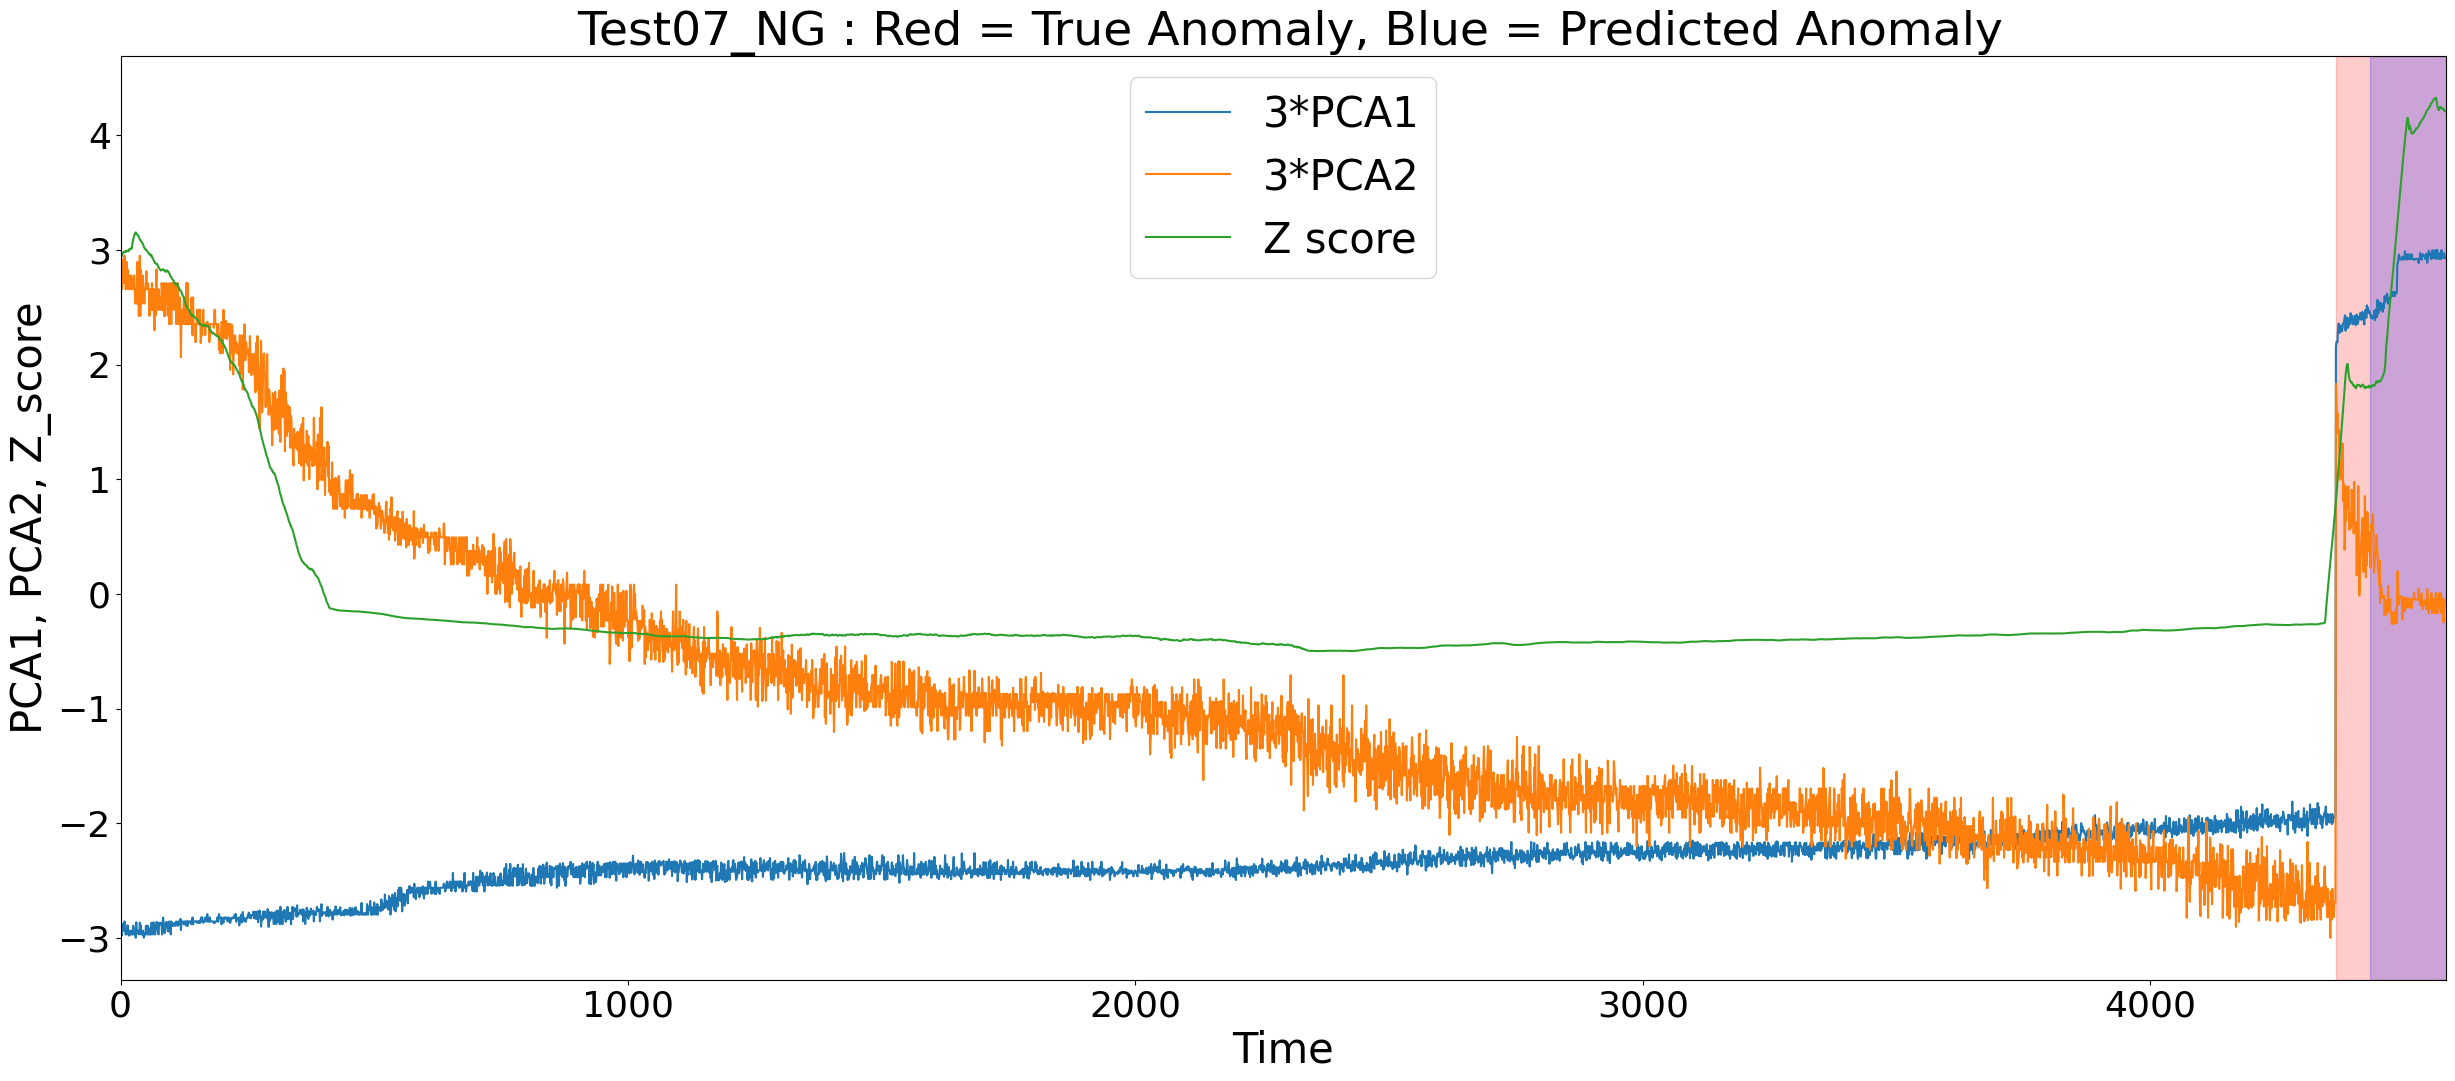

In [104]:
register_matplotlib_converters()
np.random.seed(0)
if not isinstance(anomalies_plot, list):
 anomalies_plot = [anomalies_plot]
fig = plt.figure(figsize=(30, 12))
ax = fig.add_subplot(111)
max_len = length_anom-10
time =range(max_len)
Z_score2 = Z_score1[:max_len]
X_signal = []
for kk in range(max_len):
 X_signal.append(X[kk, 1])
for kk in range(10):
 print( X[kk, 1] )
X_signal_2 = np.array(X_signal)
plt.plot(time, 3*X_signal_2[:, 0], label='3*PCA1')
plt.plot(time, 3*X_signal_2[:, 1], label='3*PCA2')
plt.plot(time, Z_score2, label='Z score')
plt.legend(loc=0, fontsize=30)
print("length_anom, max_len:", length_anom, max_len)


colors = ['red'] + ['blue'] * (len(anomalies_plot)-1)
for i, anom_span in enumerate(anomalies_plot):
 if not isinstance(anom_span, list):
    anom_span = list(anom_span[['start', 'end']].itertuples(index=False))
 for _, anom in enumerate(anom_span):
    t1 = anom[0]
    t2 = anom[1]
    plt.axvspan(t1, t2, color=colors[i], alpha=0.2)
plt.title(' Test07_NG : Red = True Anomaly, Blue = Predicted Anomaly', size=34)
plt.ylabel('PCA1, PCA2, Z_score', size=30)
plt.xlabel('Time', size=30)
plt.xticks(size=26)
plt.yticks(size=26)
plt.xlim([time[0], time[-1]])
plt.show()

C:\Users\Leejunseong\AppData\Local\Temp\ipykernel_44376\3697695688.py:47: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from current font.
  plt.tight_layout()
C:\Users\Leejunseong\AppData\Local\Temp\ipykernel_44376\3697695688.py:47: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\Leejunseong\AppData\Local\Temp\ipykernel_44376\3697695688.py:47: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  plt.tight_layout()
c:\Users\Leejunseong\anaconda3\envs\kmap_1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Leejunseong\anaconda3\envs\kmap_1\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Leejunseong\anaconda3\envs\kmap_1\lib\site-

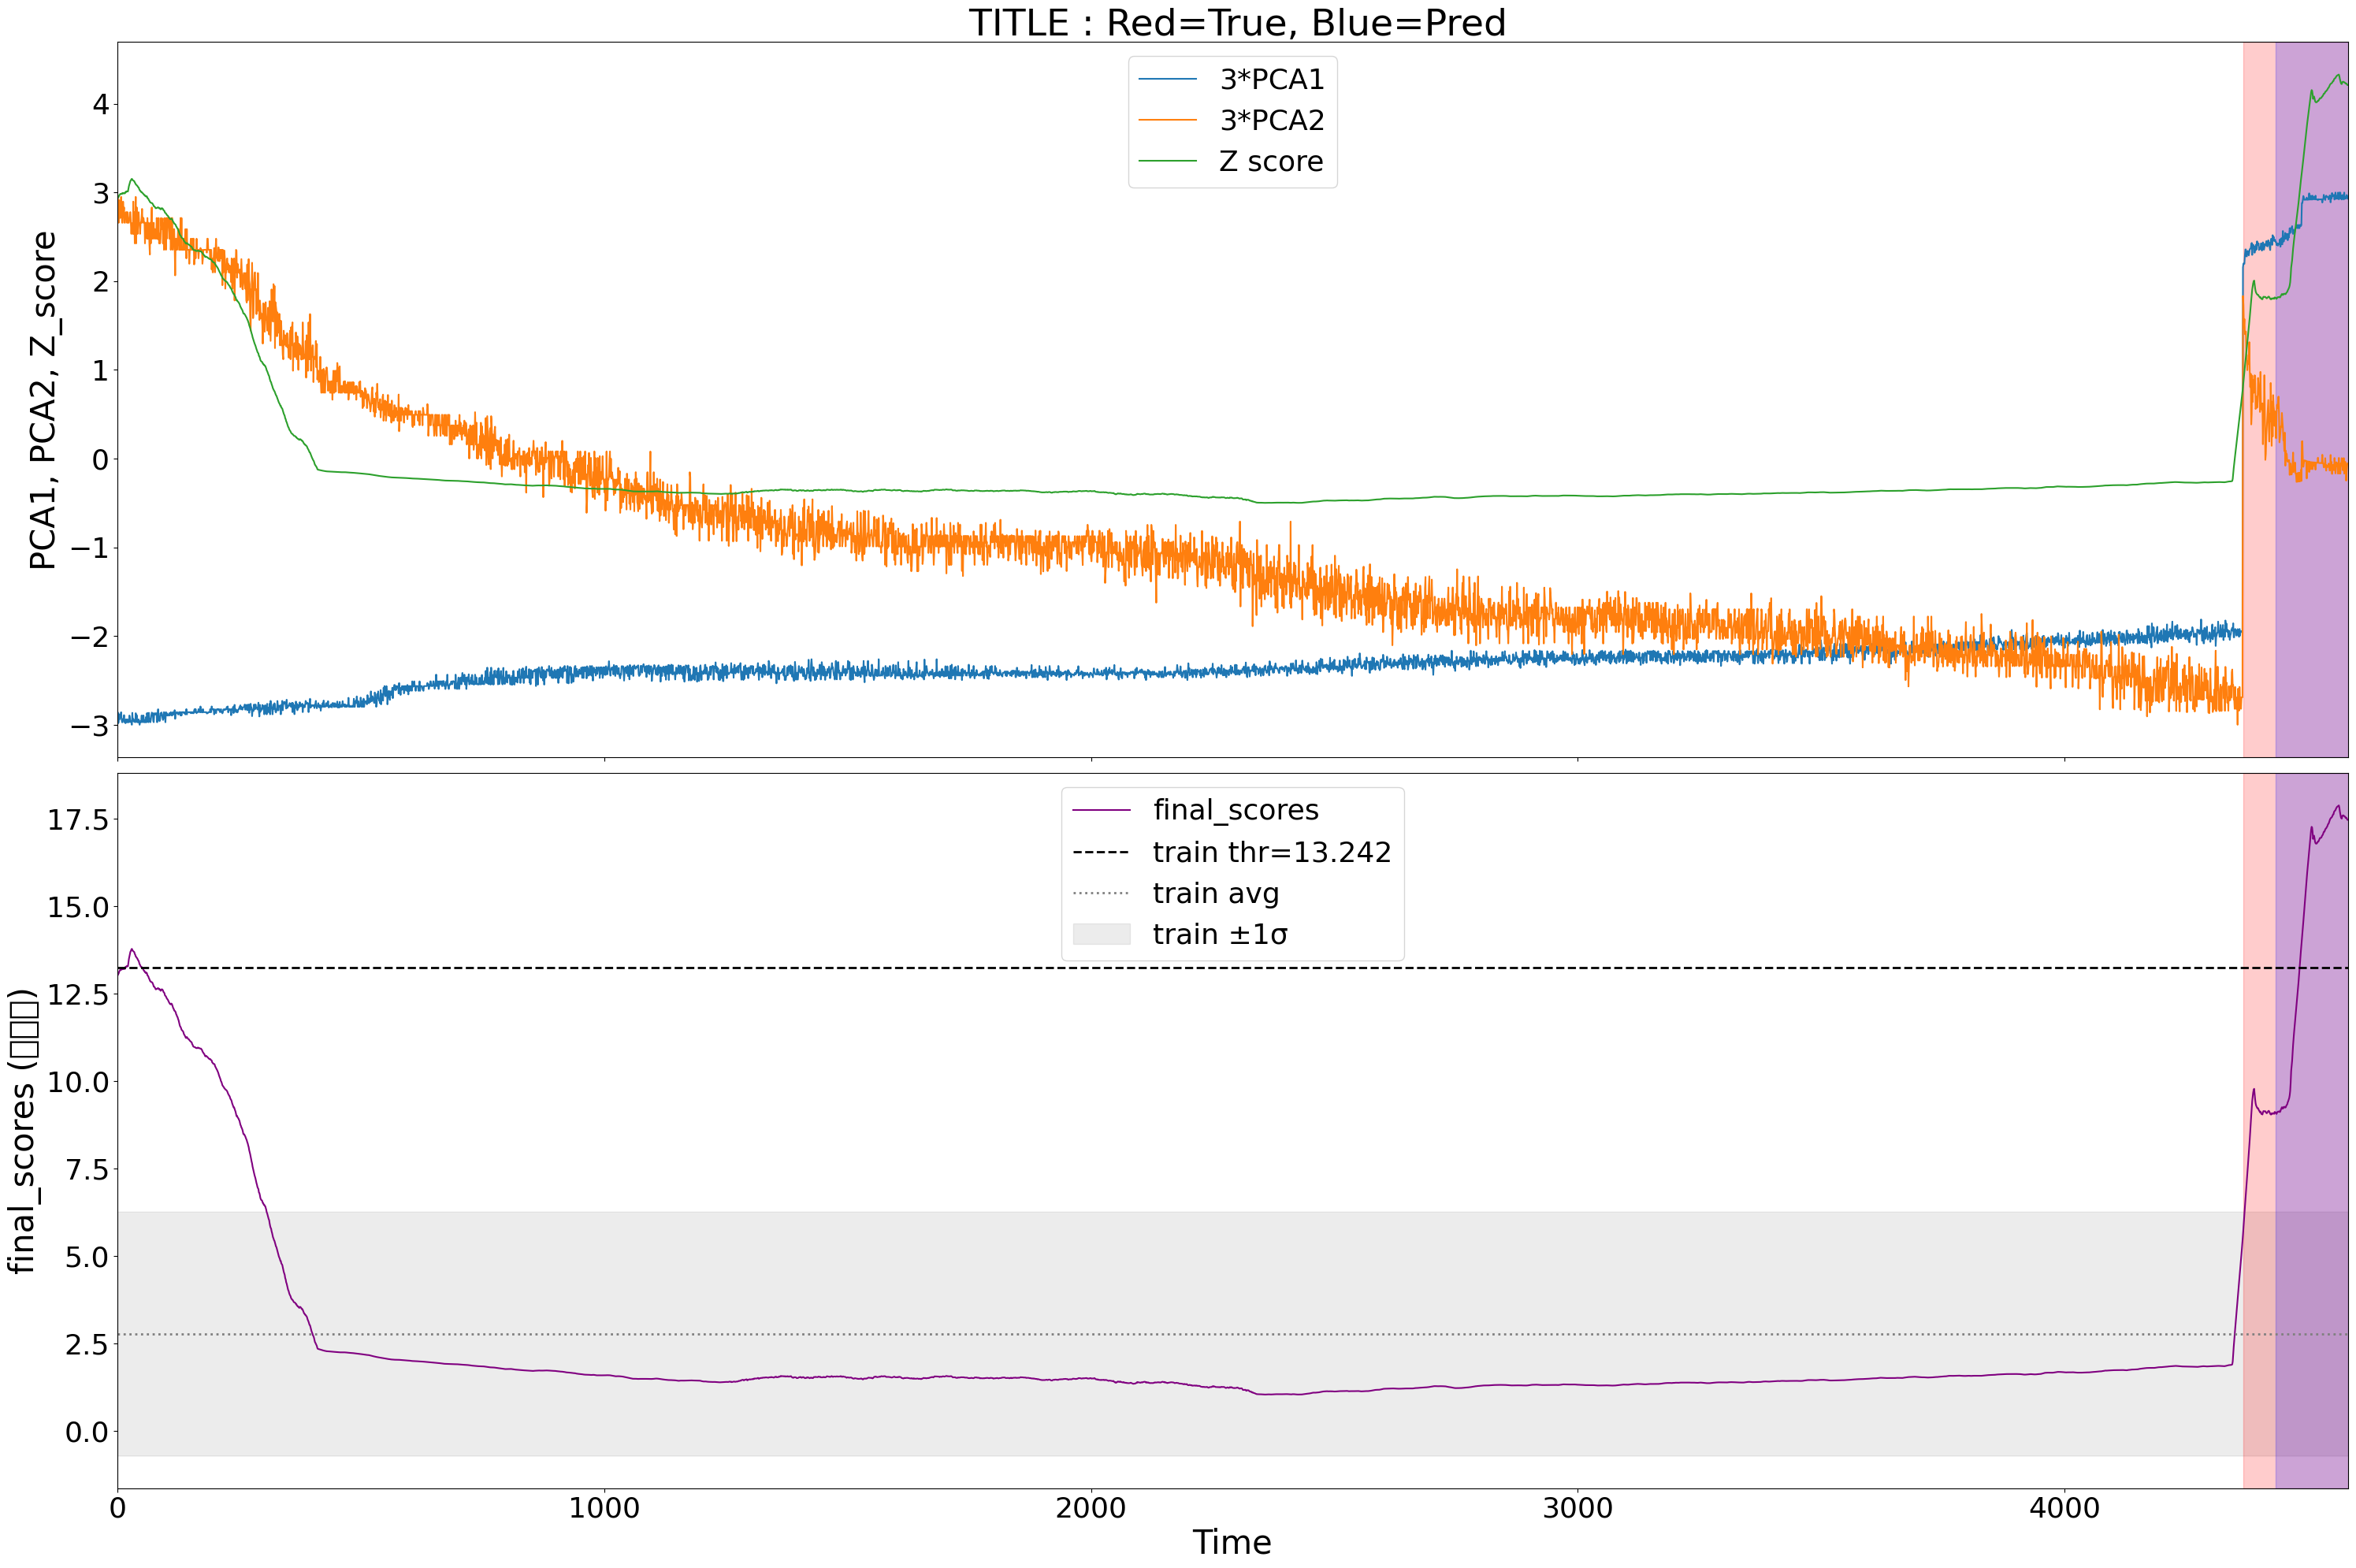

In [106]:
errors = final_scores
threshold = anomaly._fixed_threshold(errors) 

register_matplotlib_converters()
np.random.seed(0)
max_len = min(length_anom - 10, len(X))
t = range(max_len)
Z2 = Z_score1[:max_len]
X_sig = np.array([X[kk, 1] for kk in range(max_len)])
final_scores_plot = final_scores[:max_len]                # ★ 추가: 원점수(절대값)

colors = ['red'] + ['blue'] * (len(anomalies_plot) - 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 20), sharex=True)

# ---- 위: 기존 그래프 (PCA + Z-score, 상대값) ----
ax1.plot(t, 3 * X_sig[:, 0], label='3*PCA1')
ax1.plot(t, 3 * X_sig[:, 1], label='3*PCA2')
ax1.plot(t, Z2, label='Z score')
ax1.legend(loc=0, fontsize=26)
for i, anom_span in enumerate(anomalies_plot):
    for anom in anom_span:
        ax1.axvspan(anom[0], anom[1], color=colors[i], alpha=0.2)
ax1.set_title(' {} : Red=True, Blue=Pred'.format("TITLE"), size=34)
ax1.set_ylabel('PCA1, PCA2, Z_score', size=30)
ax1.tick_params(labelsize=26)

# ---- 아래: final_scores 원점수 + train 기준선 (절대값, 실제 판정 근거) ----
ax2.plot(t, final_scores_plot, label='final_scores', color='purple')
ax2.axhline(threshold, color='black', linestyle='--', linewidth=2,
            label=f'train thr={threshold:.3f}')
ax2.axhline(final_scores.mean(), color='gray', linestyle=':', linewidth=2,
            label='train avg')
ax2.fill_between(t,
                  final_scores.mean() - final_scores.std(),
                  final_scores.mean() + final_scores.std(),
                  color='gray', alpha=0.15, label='train ±1σ')
for i, anom_span in enumerate(anomalies_plot):
    for anom in anom_span:
        ax2.axvspan(anom[0], anom[1], color=colors[i], alpha=0.2)
ax2.legend(loc=0, fontsize=26)
ax2.set_ylabel('final_scores (절대값)', size=30)
ax2.set_xlabel('Time', size=30)
ax2.tick_params(labelsize=26)

plt.xlim([t[0], t[-1]])
plt.tight_layout()
plt.show()


## 추가 검증 코드

In [ ]:
from scipy import stats
import numpy as np

true0 = anom_labels
print("true0 :")
print(true0.tail(40))

pred_length = len(final_scores)

# Z-score 계산
Z_score1 = stats.zscore(final_scores)

# 이상 구간 binary로 변환 (수정된 부분)
pred_bin = [0] * pred_length
for i in range(len(anomalies)):
    if len(anomalies[i]) > 0:  # ✅ 빈 리스트 체크
        start, stop = anomalies[i][0]  # ✅ 튜플 언팩
        print(f"탐지 구간 {i}: {start} ~ {stop}")
        for k in range(int(start)-1, int(stop)):  # ✅ int로 변환
            if k < pred_length:
                pred_bin[k] = 1

# True/Pred 준비
true = np.array(true0[:pred_length])
pred = np.array(pred_bin)

# Confusion Matrix 계산
tp = np.sum((pred == 1) & (true == 1))
tn = np.sum((pred == 0) & (true == 0))
fp = np.sum((pred == 1) & (true == 0))
fn = np.sum((pred == 0) & (true == 1))

# 성능 지표 계산
Accuracy = (tp + tn) / len(pred)
Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
Recall = tp / (tp + fn) if (tp + fn) > 0 else 0

# F1 안전하게 계산
if Precision + Recall == 0:
    F1_score = 0
else:
    F1_score = 2.0 * (Precision * Recall) / (Precision + Recall)

print("Accuracy : {:0.4f}, Precision : {:0.4f}, Recall : {:0.4f}, F-score : {:0.4f}".format(
    Accuracy, Precision, Recall, F1_score))

print("\n=== Confusion Matrix ===")
print(f"TP: {tp}, FP: {fp}")
print(f"FN: {fn}, TN: {tn}")

true0 :
4554    1
4555    1
4556    1
4557    1
4558    1
4559    1
4560    1
4561    1
4562    1
4563    1
4564    1
4565    1
4566    1
4567    1
4568    1
4569    1
4570    1
4571    1
4572    1
4573    1
4574    1
4575    1
4576    1
4577    1
4578    1
4579    1
4580    1
4581    1
4582    1
4583    1
4584    1
4585    1
4586    1
4587    1
4588    1
4589    1
4590    1
4591    1
4592    1
4593    1
Name: label, dtype: int64
Accuracy : 0.9508, Precision : 0.0000, Recall : 0.0000, F-score : 0.0000

=== Confusion Matrix ===
TP: 0, FP: 0
FN: 226, TN: 4367


In [ ]:
print("=== 현재 상태 진단 ===")
print(f"현재 분석 파일: {args.signal_file}")   # 지금 무슨 파일인지
print(f"final_scores 길이: {len(final_scores)}")
print(f"final_scores 범위: {np.min(final_scores):.3f} ~ {np.max(final_scores):.3f}")
print(f"final_scores 평균: {np.mean(final_scores):.3f}, 표준편차: {np.std(final_scores):.3f}")

# find_anomalies가 쓰는 threshold 직접 계산
threshold = np.mean(final_scores) + 3 * np.std(final_scores)
print(f"\nthreshold (평균+3σ): {threshold:.3f}")
print(f"threshold 넘는 지점 개수: {np.sum(final_scores > threshold)}")

=== 현재 상태 진단 ===
현재 분석 파일: ./data/preprocessed/test/Test07_NG_dchg.csv
final_scores 길이: 4593
final_scores 범위: 1.192 ~ 12.922
final_scores 평균: 2.393, 표준편차: 1.860

threshold (평균+3σ): 7.973
threshold 넘는 지점 개수: 201


In [ ]:
# find_anomalies가 threshold를 어떻게 잡는지 직접 확인
errors = final_scores
threshold = anomaly._fixed_threshold(errors)   # 함수가 쓰는 실제 threshold
print(f"find_anomalies 내부 threshold: {threshold:.3f}")
print(f"final_scores 최댓값: {np.max(errors):.3f}")
print(f"threshold 넘는 지점: {np.sum(errors > threshold)}개")

# 실제로 find_anomalies 돌려서 결과 확인
result = anomaly.find_anomalies(final_scores, true_index)
print(f"\nfind_anomalies 반환값: {result}")
print(f"반환 개수: {len(result)}")

find_anomalies 내부 threshold: 7.973
final_scores 최댓값: 12.922
threshold 넘는 지점: 201개
start 4342.0
stop 4592.0
score 1.1636764518538107

find_anomalies 반환값: [[4343, 4593, 1.1636764518538107]]
반환 개수: 1


In [ ]:
import pandas as pd

train_cols = set(pd.read_csv('./data/preprocessed/train/1000_chg.csv').columns)
test_cols  = set(pd.read_csv('./data/preprocessed/test/Test07_NG_dchg.csv').columns)

print("학습 컬럼 수:", len(train_cols))
print("테스트 컬럼 수:", len(test_cols))
print("공통 컬럼 수:", len(train_cols & test_cols))
print("학습에만 있는 컬럼:", sorted(train_cols - test_cols)[:10])
print("테스트에만 있는 컬럼:", sorted(test_cols - train_cols)[:10])

학습 컬럼 수: 208
테스트 컬럼 수: 208
공통 컬럼 수: 207
학습에만 있는 컬럼: ['Tavg']
테스트에만 있는 컬럼: ['M16T02']


In [ ]:
# List of Anomaly sequences
anomalies = []
anomaly_gt = []
anomaly_pred = []
length_anom =len(pred)
print("length_anom: ", length_anom)
anom_pred_init =0 # inside a sequence or not
anom_gt_init =0 #
for k in range(length_anom):
 if gt[k] ==1 :
    if anom_gt_init ==0 : # Now beginning of an anomalous sequence.
        anom_gt_begin = k
        anom_gt_init =1
    else :
        anom_gt_end = k
        if k == length_anom-1:
            anomaly_gt.append((anom_gt_begin,anom_gt_end))
    if gt[k] ==0 and anom_gt_init ==1: # End of anom. sequence
        anom_gt_end = k -1
        anomaly_gt.append((anom_gt_begin,anom_gt_end))
        anom_gt_init =0
    if pred[k] ==1 :
        if anom_pred_init ==0 : # Now beginning of an anomalous sequence.
            anom_pred_begin = k
            anom_pred_init =1
        else :
            anom_pred_end = k
            if k == length_anom -1:
                anomaly_pred.append((anom_pred_begin,anom_pred_end))
    if pred[k] ==0 and anom_pred_init ==1: # End of anom. sequence
        anom_pred_end = k -1
        anomaly_pred.append((anom_pred_begin,anom_pred_end))
        anom_pred_init =0
anomalies_plot = [anomaly_gt, anomaly_pred]
print("gt:")
print(anomaly_gt)
print("pred:")
print(anomaly_pred)

length_anom:  4593
gt:
[(4367, 4592)]
pred:
[(4367, 4592)]


In [ ]:
# List of Anomaly sequences
anomalies = []
anomaly_gt = []
anomaly_pred = []
length_anom =len(pred)
print("length_anom: ", length_anom)
anom_pred_init =0 # inside a sequence or not
anom_gt_init =0 #
for k in range(length_anom):
 if gt[k] ==1 :
    if anom_gt_init ==0 : # Now beginning of an anomalous sequence.
        anom_gt_begin = k
        anom_gt_init =1
    else :
        anom_gt_end = k
        if k == length_anom-1:
            anomaly_gt.append((anom_gt_begin,anom_gt_end))
    if gt[k] ==0 and anom_gt_init ==1: # End of anom. sequence
        anom_gt_end = k -1
        anomaly_gt.append((anom_gt_begin,anom_gt_end))
        anom_gt_init =0
    if pred[k] ==1 :
        if anom_pred_init ==0 : # Now beginning of an anomalous sequence.
            anom_pred_begin = k
            anom_pred_init =1
        else :
            anom_pred_end = k
            if k == length_anom -1:
                anomaly_pred.append((anom_pred_begin,anom_pred_end))
    if pred[k] ==0 and anom_pred_init ==1: # End of anom. sequence
        anom_pred_end = k -1
        anomaly_pred.append((anom_pred_begin,anom_pred_end))
        anom_pred_init =0
anomalies_plot = [anomaly_gt, anomaly_pred]
print("gt:")
print(anomaly_gt)
print("pred:")
print(anomaly_pred)

length_anom:  4593
gt:
[(4367, 4592)]
pred:
[(4367, 4592)]
